# <h1 style='background:#66CDAA; border:2; border-radius: 10px; font-size:250%; font-weight: bold; color:black'><center>College Student Data</center></h1> 
 
<img src = "https://www.laguiadelvaron.com/wp-content/uploads/2017/11/anigif_sub-buzz-5611-1474885869-2-1.gif" width = 1600 height = 600/>

Student (from lat. studens "a hard-working person engaged in work and study") - a student of higher education, in some states and countries and secondary educational institutions.

In ancient Rome and in the Middle Ages, researchers named any person, capturing the process of cognition. With the foundation in the XII study of universities, the term began to be used for persons studying and teaching in them; after the introduction of academic titles for teachers (master, professor, and others), only students. In higher education institutions (HEI), where education is conducted at the bachelor's and master's levels (Bologna system), the definition of a student for the education of steps, for example, a bachelor's student, a master's student.

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
    
<h1 style='background:#66CDAA; border:0; border-radius: 10px; color:black'><center> TABLE OF CONTENTS </center></h1>

### [**1. IMPORTING LIBRARIES AND LOADING DATA**](#title-one)

### [**2. DATA INFORMATION**](#title-two)

### [**3. EXPLORATORY DATA ANALYSIS**](#title-three)

### [**4. STATISTICAL TESTS**](#title-four)

### [**5. MACHINE LEARNING AND CLUSTER ANALYSIS**](#title-five)

### [**6. CONCLUSIONS AND RECOMENDATIONS**](#title-six)
    
<a id="title-one"></a>
<h1 style='background:#66CDAA; border:2; border-radius: 10px; color:black'><center>IMPORTING LIBRARIES AND LOADING DATA</center></h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import missingno as msno
from scipy import stats
import plotly
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots
from plotly.offline import iplot, init_notebook_mode

In [2]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor

In [3]:
train = pd.read_csv('../input/cpga-iq-placement/student_clustering.csv')

<a id="title-two"></a>
<h1 style='background:#66CDAA; border:2; border-radius: 10px; color:black'><center>DATA INFORMATION</center></h1>

Let's look at our dataset

In [4]:
train

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110
...,...,...
195,4.68,89
196,8.57,118
197,5.85,112
198,6.23,108


Information about two hundred students is presented as well as their average grades and iq level. What is data?
* The cumulative GPA is simply called the CGPA. This is the average student's GPA that he received at the college or university in the courses he took. To qualify for the CGPA, a student's scores for all semesters are added together and divided by the sum of their total credit hours. If there are two semesters in a year, the student receives the CGPA for the year, and the grades for the semester give him the SGPA. So, if the degree course is 8 semesters, just add up the SGPA and divide by 8 to get the student's CGPA.
* An intelligence quotient (IQ) is a total score derived from a set of standardized tests or subtests designed to assess human intelligence. The abbreviation "IQ" was coined by the psychologist William Stern for the German term Intelligenzquotient, his term for a scoring method for intelligence tests at University of Breslau he advocated in a 1912 book.Historically, IQ was a score obtained by dividing a person's mental age score, obtained by administering an intelligence test, by the person's chronological age, both expressed in terms of years and months. The resulting fraction (quotient) was multiplied by 100 to obtain the IQ score. For modern IQ tests, the raw score is transformed to a normal distribution with mean 100 and standard deviation 15.This results in approximately two-thirds of the population scoring between IQ 85 and IQ 115 and about 2.5 percent each above 130 and below 70.

Let's look at the statistics of our dataset.

In [5]:
train.describe().style.background_gradient(cmap = "summer")

,cgpa,iq
count,200.000000,200.000000
mean,6.983400,101.995000
std,1.624101,12.161599
min,4.600000,83.000000
25%,5.407500,91.000000
50%,7.040000,102.000000
75%,8.585000,113.000000
max,9.300000,121.000000


How did a person with an IQ=83 become a college student? Why is the maximum IQ value only 121? It is very interesting in which higher educational institution they collected material for this dataset :)

Hypothesis: There are minor outliers in the iq data.

Let's look at the type of data presented in the dataset.

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   cgpa    200 non-null    float64
 1   iq      200 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.2 KB


Great, you can immediately start analyzing the data without significant dataset transformations.

<a id="title-three"></a>
<h1 style='background:#66CDAA; border:2; border-radius: 10px; color:black'><center>EXPLORATORY DATA ANALYSIS</center></h1>

Let's evaluate the information gaps in the dataset.

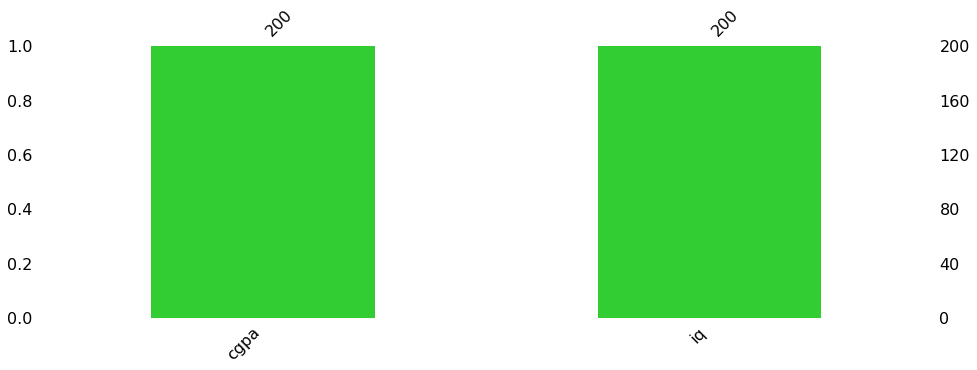

In [7]:
msno.bar(train, figsize = (16,5),color = "#32CD32")
plt.show()

There are no gaps, which means that the dataset will display information that corresponds to reality.

Let's check our dataset for duplicates.

In [8]:
train.duplicated().sum()

7

There are duplicates of information, we will delete them.

In [9]:
train=train.drop_duplicates(keep='last')

Let's carry out a mini analysis of the information present in the dataset.

Text(0.5, 0.98, 'Visualizing continuous columns (train dataset)')

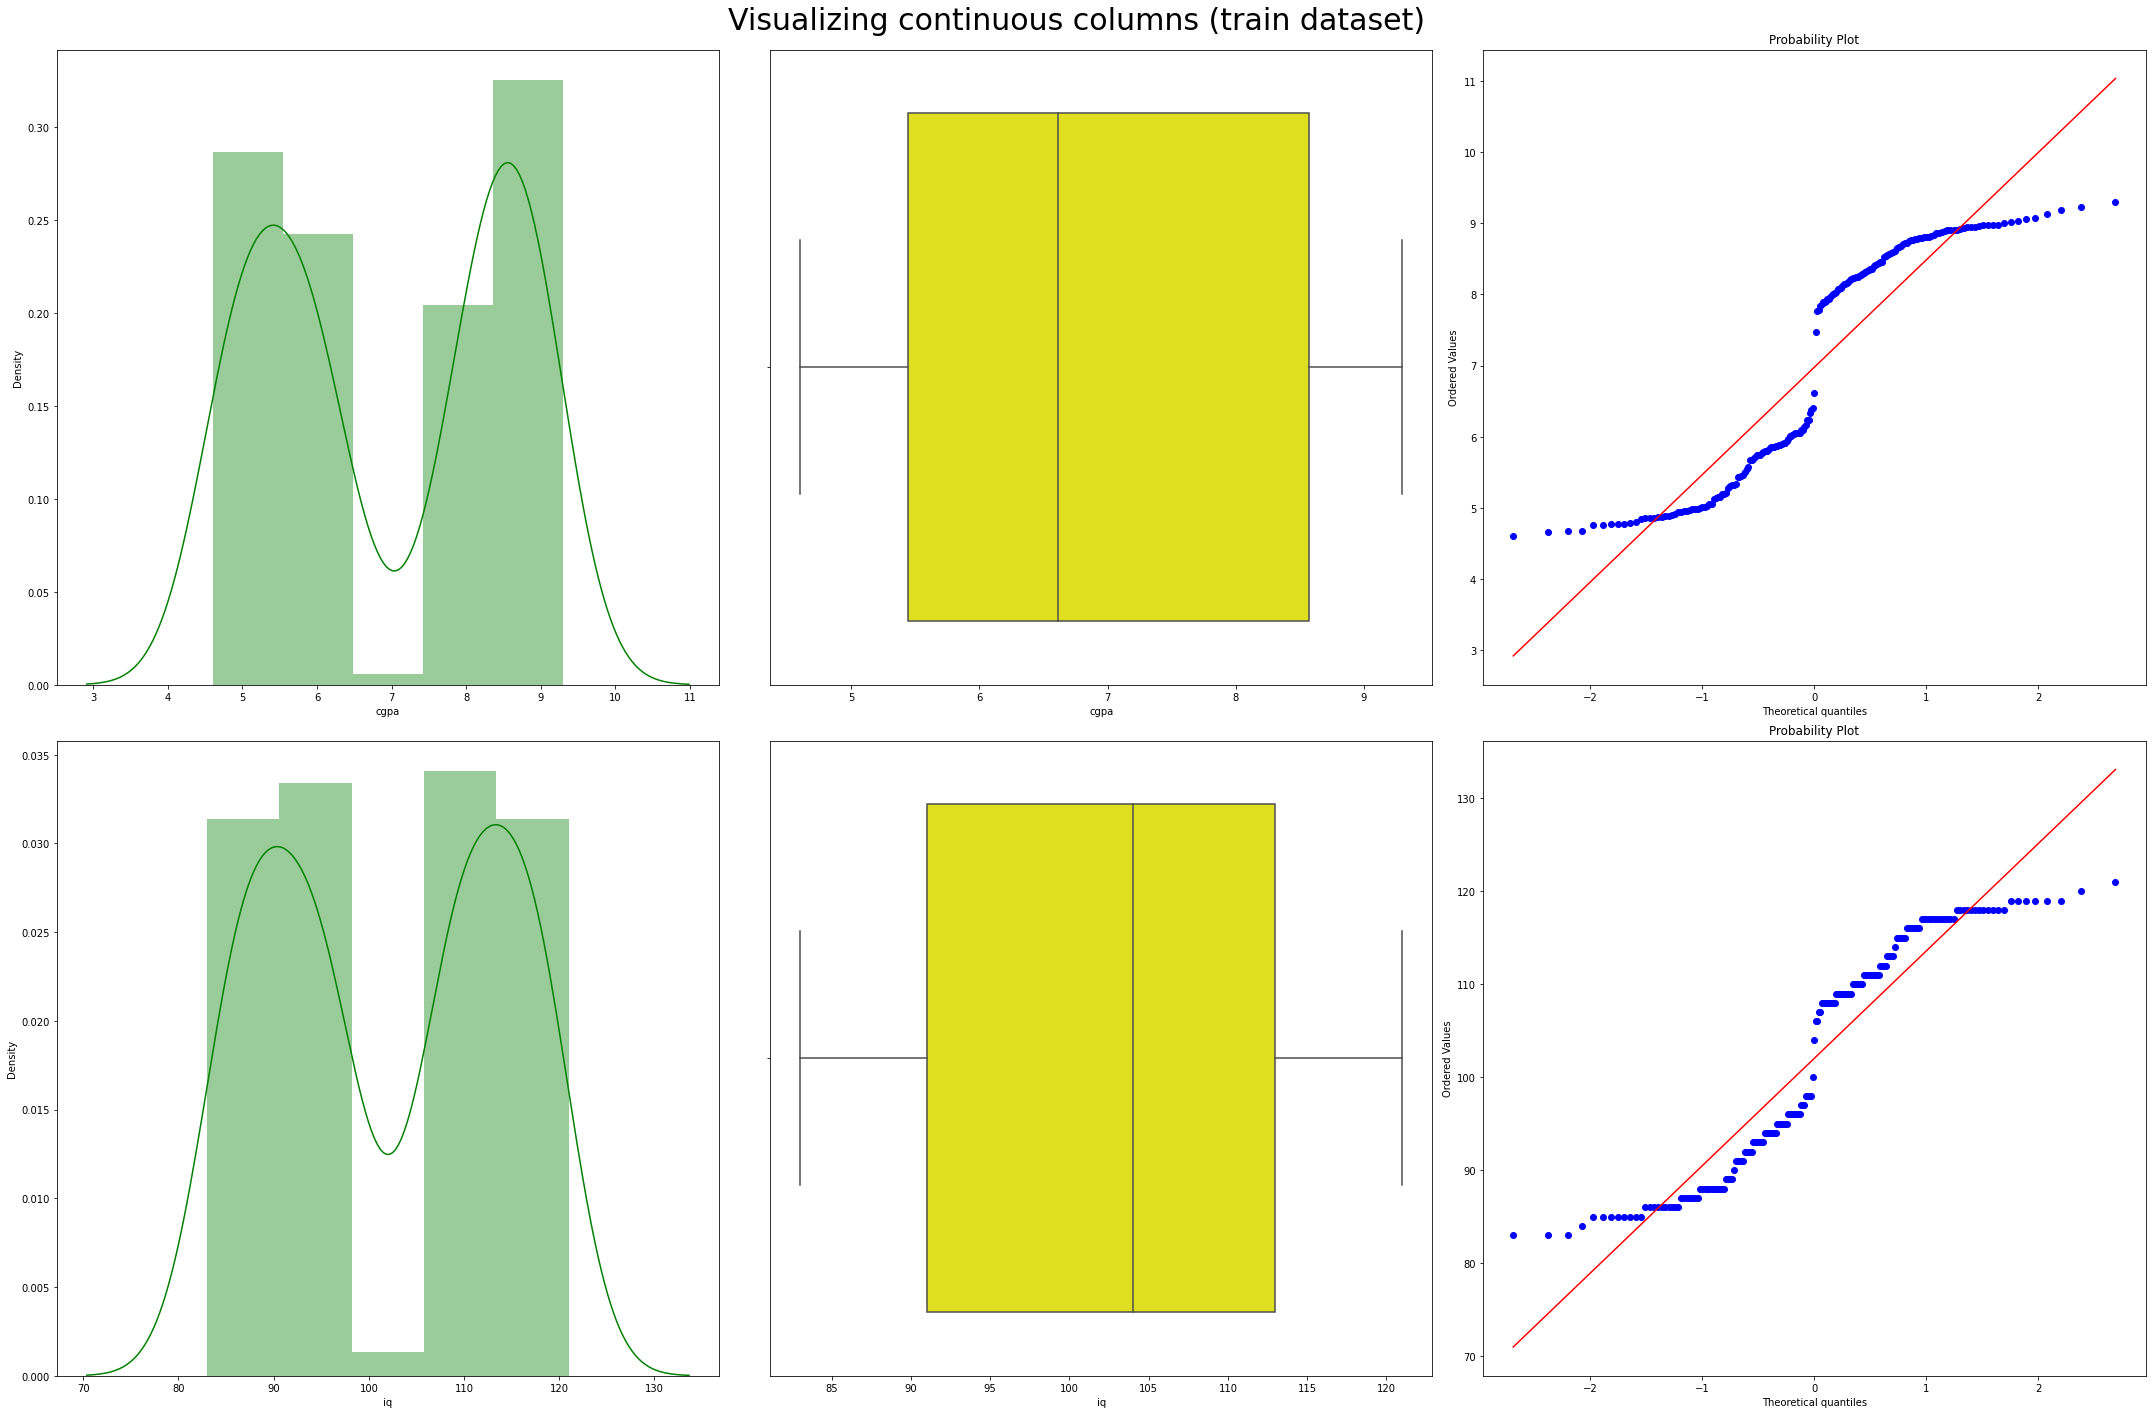

In [10]:
import warnings
warnings.filterwarnings('ignore')
fig,ax = plt.subplots(len(train.columns),3,figsize=(30,20))
for index,i in enumerate(train.columns):
    sns.distplot(train[i],ax=ax[index,0],color='green')
    sns.boxplot(train[i],ax=ax[index,1],color='yellow')
    stats.probplot(train[i],plot=ax[index,2])
    
fig.tight_layout()
fig.subplots_adjust(top=0.95)
plt.suptitle("Visualizing continuous columns (train dataset)",fontsize=30)

Let's look at the scatter plot.

In [11]:
fig = px.scatter(train, x='iq',y='cgpa',template="ggplot2")
fig.update_layout(title="Distribution of student indicators")
fig.show()

What conclusions can be drawn from the presented graphs?
* Feature distributions are bimodal. The modes for CGPA are 5.5 and 8.5, for IQ=90 and 115. This indicates that at least 2 large groups of students are represented in the data.
* The relationship between our features shows that the data is divided into 4 main groups.

<a id="title-four"></a>
<h1 style='background:#66CDAA; border:2; border-radius: 10px; color:black'><center>STATISTICAL TESTS</center></h1>

First, let's explore the relationship of features. To do this, we use a correlation matrix.

In [12]:
correlation = train.corr()
print(correlation['iq'].sort_values(ascending = False),'\n')

iq      1.000000
cgpa    0.517675
Name: iq, dtype: float64 



There is a weak correlation between the two traits.

Let us check the hypotheses about the normality of the distribution of features. It follows from the distribution plots that the distribution is not normal and has a bimodal distribution.

In [13]:
# Shapiro-Wilk Test
from scipy.stats import shapiro
# normality test
for feature in train.columns:
	stat, p = shapiro(train[feature])
	print('Statistics=%.3f, p=%.3f' % (stat, p))
	# interpret
	alpha = 0.05
	if p > alpha:
		print(f'Sample {feature} looks Gaussian (fail to reject H0),')
	else:
		print(f'Sample {feature} does not look Gaussian (reject H0)')

Statistics=0.853, p=0.000
Sample cgpa does not look Gaussian (reject H0)
Statistics=0.894, p=0.000
Sample iq does not look Gaussian (reject H0)


Hypothesis confirmed :)

<a id="title-five"></a>
<h1 style='background:#66CDAA; border:2; border-radius: 10px; color:black'><center>MACHINE LEARNING AND CLUSTER ANALYSIS</center></h1>

To confirm the assumption about the expediency of clustering in 4 groups, we will conduct a small experiment with partitioning our space into clusters using the k-means algorithm.

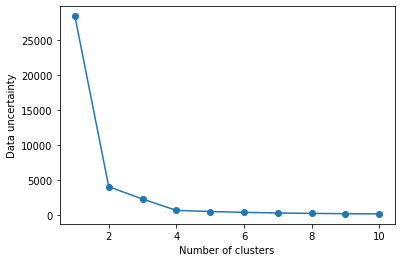

In [14]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    km = KMeans(n_clusters=i)
    km.fit_predict(train)
    wcss.append(km.inertia_)
fig, ax = plt.subplots()

ax.plot(range(1,11),wcss,'-o')

ax.set_xlabel('Number of clusters')
ax.set_ylabel('Data uncertainty')

plt.show()

The hypothesis about the division of space into 4 main groups was confirmed. Is it possible to carry out a correlation analysis, so that it would be possible to predict his average grades by the value of a student's IQ? Let's try!

In [15]:
y=train['cgpa']
train=train.drop(['cgpa'],axis=1)

In [16]:
X_train, X_test, y_train, y_test=train_test_split(train,y,test_size=0.2,random_state=42)

In [17]:
models = [RandomForestRegressor(), LinearRegression(),ElasticNet(), KNeighborsRegressor(),xgb.XGBRegressor()]
scores = dict()

for m in models:
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)

    print(f'model: {str(m)}')
    print(f'RMSE: {mean_squared_error(y_test,y_pred)}')
    print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
    print('-'*30, '\n')

model: RandomForestRegressor()
RMSE: 0.09465702064103475
MAE: 0.22804691884242834
------------------------------ 

model: LinearRegression()
RMSE: 1.8437297639722294
MAE: 1.2888776437975715
------------------------------ 

model: ElasticNet()
RMSE: 1.8503427208771603
MAE: 1.3020177993809559
------------------------------ 

model: KNeighborsRegressor()
RMSE: 0.09210779487179496
MAE: 0.20641025641025662
------------------------------ 

model: XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estim

The hypothesis that the value of the average grade can be predicted from the student's IQ was confirmed, but is everything so unambiguous? Does this sample reflect the properties of the general population? Unlikely. Let's proceed to the formation of conclusions on the dataset.

<a id="title-six"></a>
<h1 style='background:#66CDAA; border:2; border-radius: 10px; color:black'><center>CONCLUSIONS AND RECOMENDATIONS</center></h1>

The vast majority of people (at least at a certain stage in their lives) for some reason believe that high or, conversely, low grades received at university are a direct statement of the level of intelligence: a loser is certainly a complete fool, and an excellent student is a smart guy, even at Harvard send.
To deny the fact that there is a certain dependence of assessments on intelligence would be, perhaps, stupid. Nevertheless, the significance of this dependence is greatly exaggerated: one should not assume that a student with an average intelligence will never win a competition or an Olympiad.

If we are not talking about exceptional cases, when, for example, there are certain problems in the family that clearly interfere with the normal mental development of a student, then it is probably not worth building a cult of intelligence: the quality of education that the university can provide plays no less a role.

Do not forget about subjectivity, which, unfortunately, is also characteristic of today's realities: for some personal reasons, a teacher can easily give completely different marks for work performed at the same level.

Psychologists have a slightly different point of view: examining the results of various samples, psychologists generally confirm that intelligence somehow correlates with the grades that students receive. But there are exceptions: according to research, low grades were also received by high-IQ students who were not motivated enough to fully participate in the educational process.

# Thanks for viewing my kernel! Rate and leave comments on the work that you would like to explore and add to my work!